# Challenge: Cancer data

Objetivo:
Detectar los tumores malignos y beningnos mediante el dataset que recaba múltiples características

Aplicar el algoritmo de KNN a (data.csv)
Evaluar el rendimiento del modelo

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "data.csv"

# Load the latest version
df_cancer = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "luisdaniel2104/cancer-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df_cancer.head())

/tmp/ipykernel_10899/2753793279.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_cancer = kagglehub.load_dataset(


100%|██████████| 122k/122k [00:00<00:00, 1.05MB/s]

First 5 records:          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_

In [ ]:
#Instalado el dataset, procedemos a revisar sus caracteristicas principales.

df_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df_cancer.head(20)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,NaN


In [ ]:
df_cancer.tail(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
559,925291,B,11.51,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.04105,...,37.16,82.28,474.2,0.12980,0.25170,0.3630,0.09653,0.2112,0.08732,NaN
560,925292,B,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,...,33.17,100.20,706.7,0.12410,0.22640,0.1326,0.10480,0.2250,0.08321,NaN
561,925311,B,11.20,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.00000,...,38.30,75.19,439.6,0.09267,0.05494,0.0000,0.00000,0.1566,0.05905,NaN
562,925622,M,15.22,30.62,103.40,716.9,0.10480,0.20870,0.25500,0.09429,...,42.79,128.70,915.0,0.14170,0.79170,1.1700,0.23560,0.4089,0.14090,NaN
563,926125,M,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.14740,...,29.41,179.10,1819.0,0.14070,0.41860,0.6599,0.25420,0.2929,0.09873,NaN
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.22160,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.16280,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.14180,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.26500,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.00000,0.2871,0.07039,NaN


In [ ]:
df_cancer.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Se realiza un drop para las columnas ID y Unnamed 32, ninguna influye directamente en el diagnostico y no son necesarias, respectivamente corresponden a:


*   Columna que identifica las filas
*   Columna que puede ser un rezago de la conversion de formatos.




In [ ]:
df_cancer_copy = df_cancer.drop(['id', 'Unnamed: 32'], axis=1)
df_cancer_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [ ]:
#Se convierte la variable categorica de diagnosis en variable numerica
#Diccionario m = 1, b = 0
df_cancer_copy['diagnosis'] = df_cancer['diagnosis'].astype(str).str.strip().map({'M': 1, 'B': 0})

df_cancer_copy.head(20)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678
5,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440
6,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368
7,1,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510
8,1,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720
9,1,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750


##EDA

/tmp/ipykernel_10899/275371355.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df_cancer_copy[col], palette='viridis')


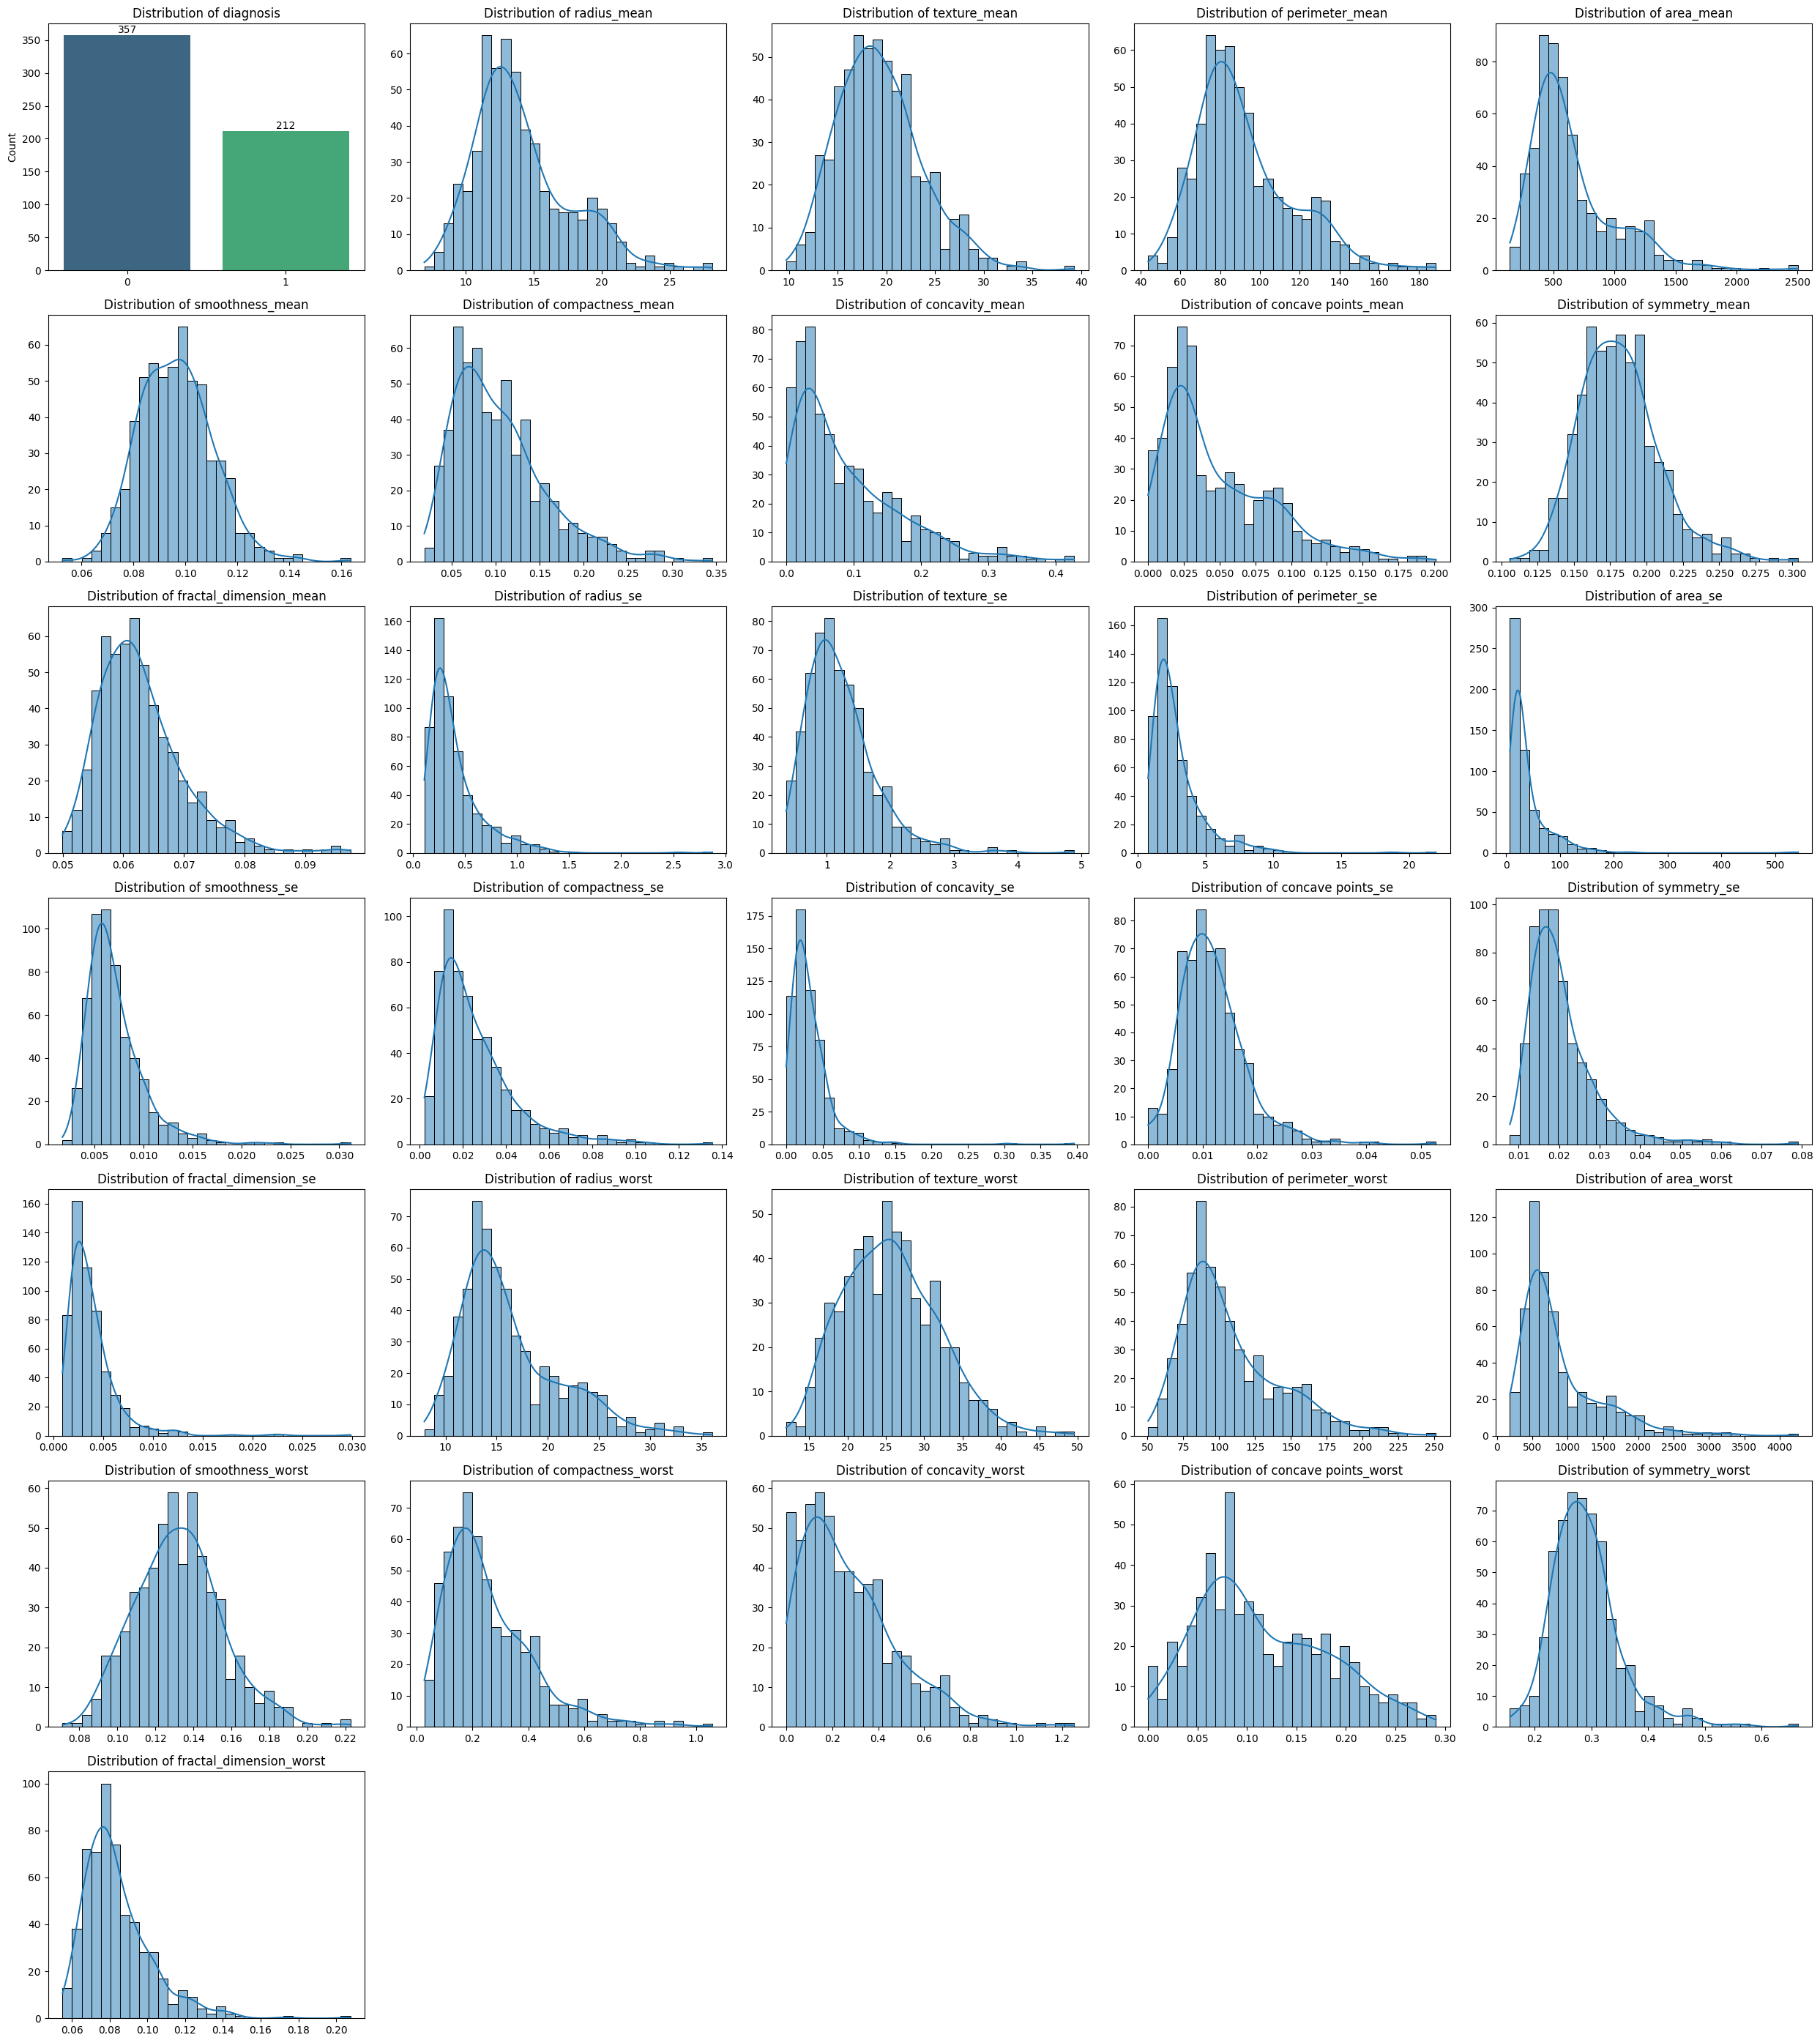

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Se convierte la variable categorica de diagnosis en variable numerica
#Diccionario m = 1, b = 0

# Get all column names from df_cancer_copy
columns = df_cancer_copy.columns.tolist()

# Determine grid size for subplots
num_columns = len(columns)
num_rows = (num_columns + 4) // 5  # Roughly 5 plots per row

plt.figure(figsize=(25, num_rows * 4))

for i, col in enumerate(columns):
    plt.subplot(num_rows, 5, i + 1)
    if col == 'diagnosis':
        ax = sns.countplot(x=df_cancer_copy[col], palette='viridis')
        plt.title(f'Distribution of {col}', fontsize=12)
        plt.xlabel('')
        plt.ylabel('Count')
        for container in ax.containers:
            ax.bar_label(container, fmt='%d')
    else:
        sns.histplot(df_cancer_copy[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}', fontsize=12)
        plt.xlabel('')
        plt.ylabel('')

plt.tight_layout()
plt.show()

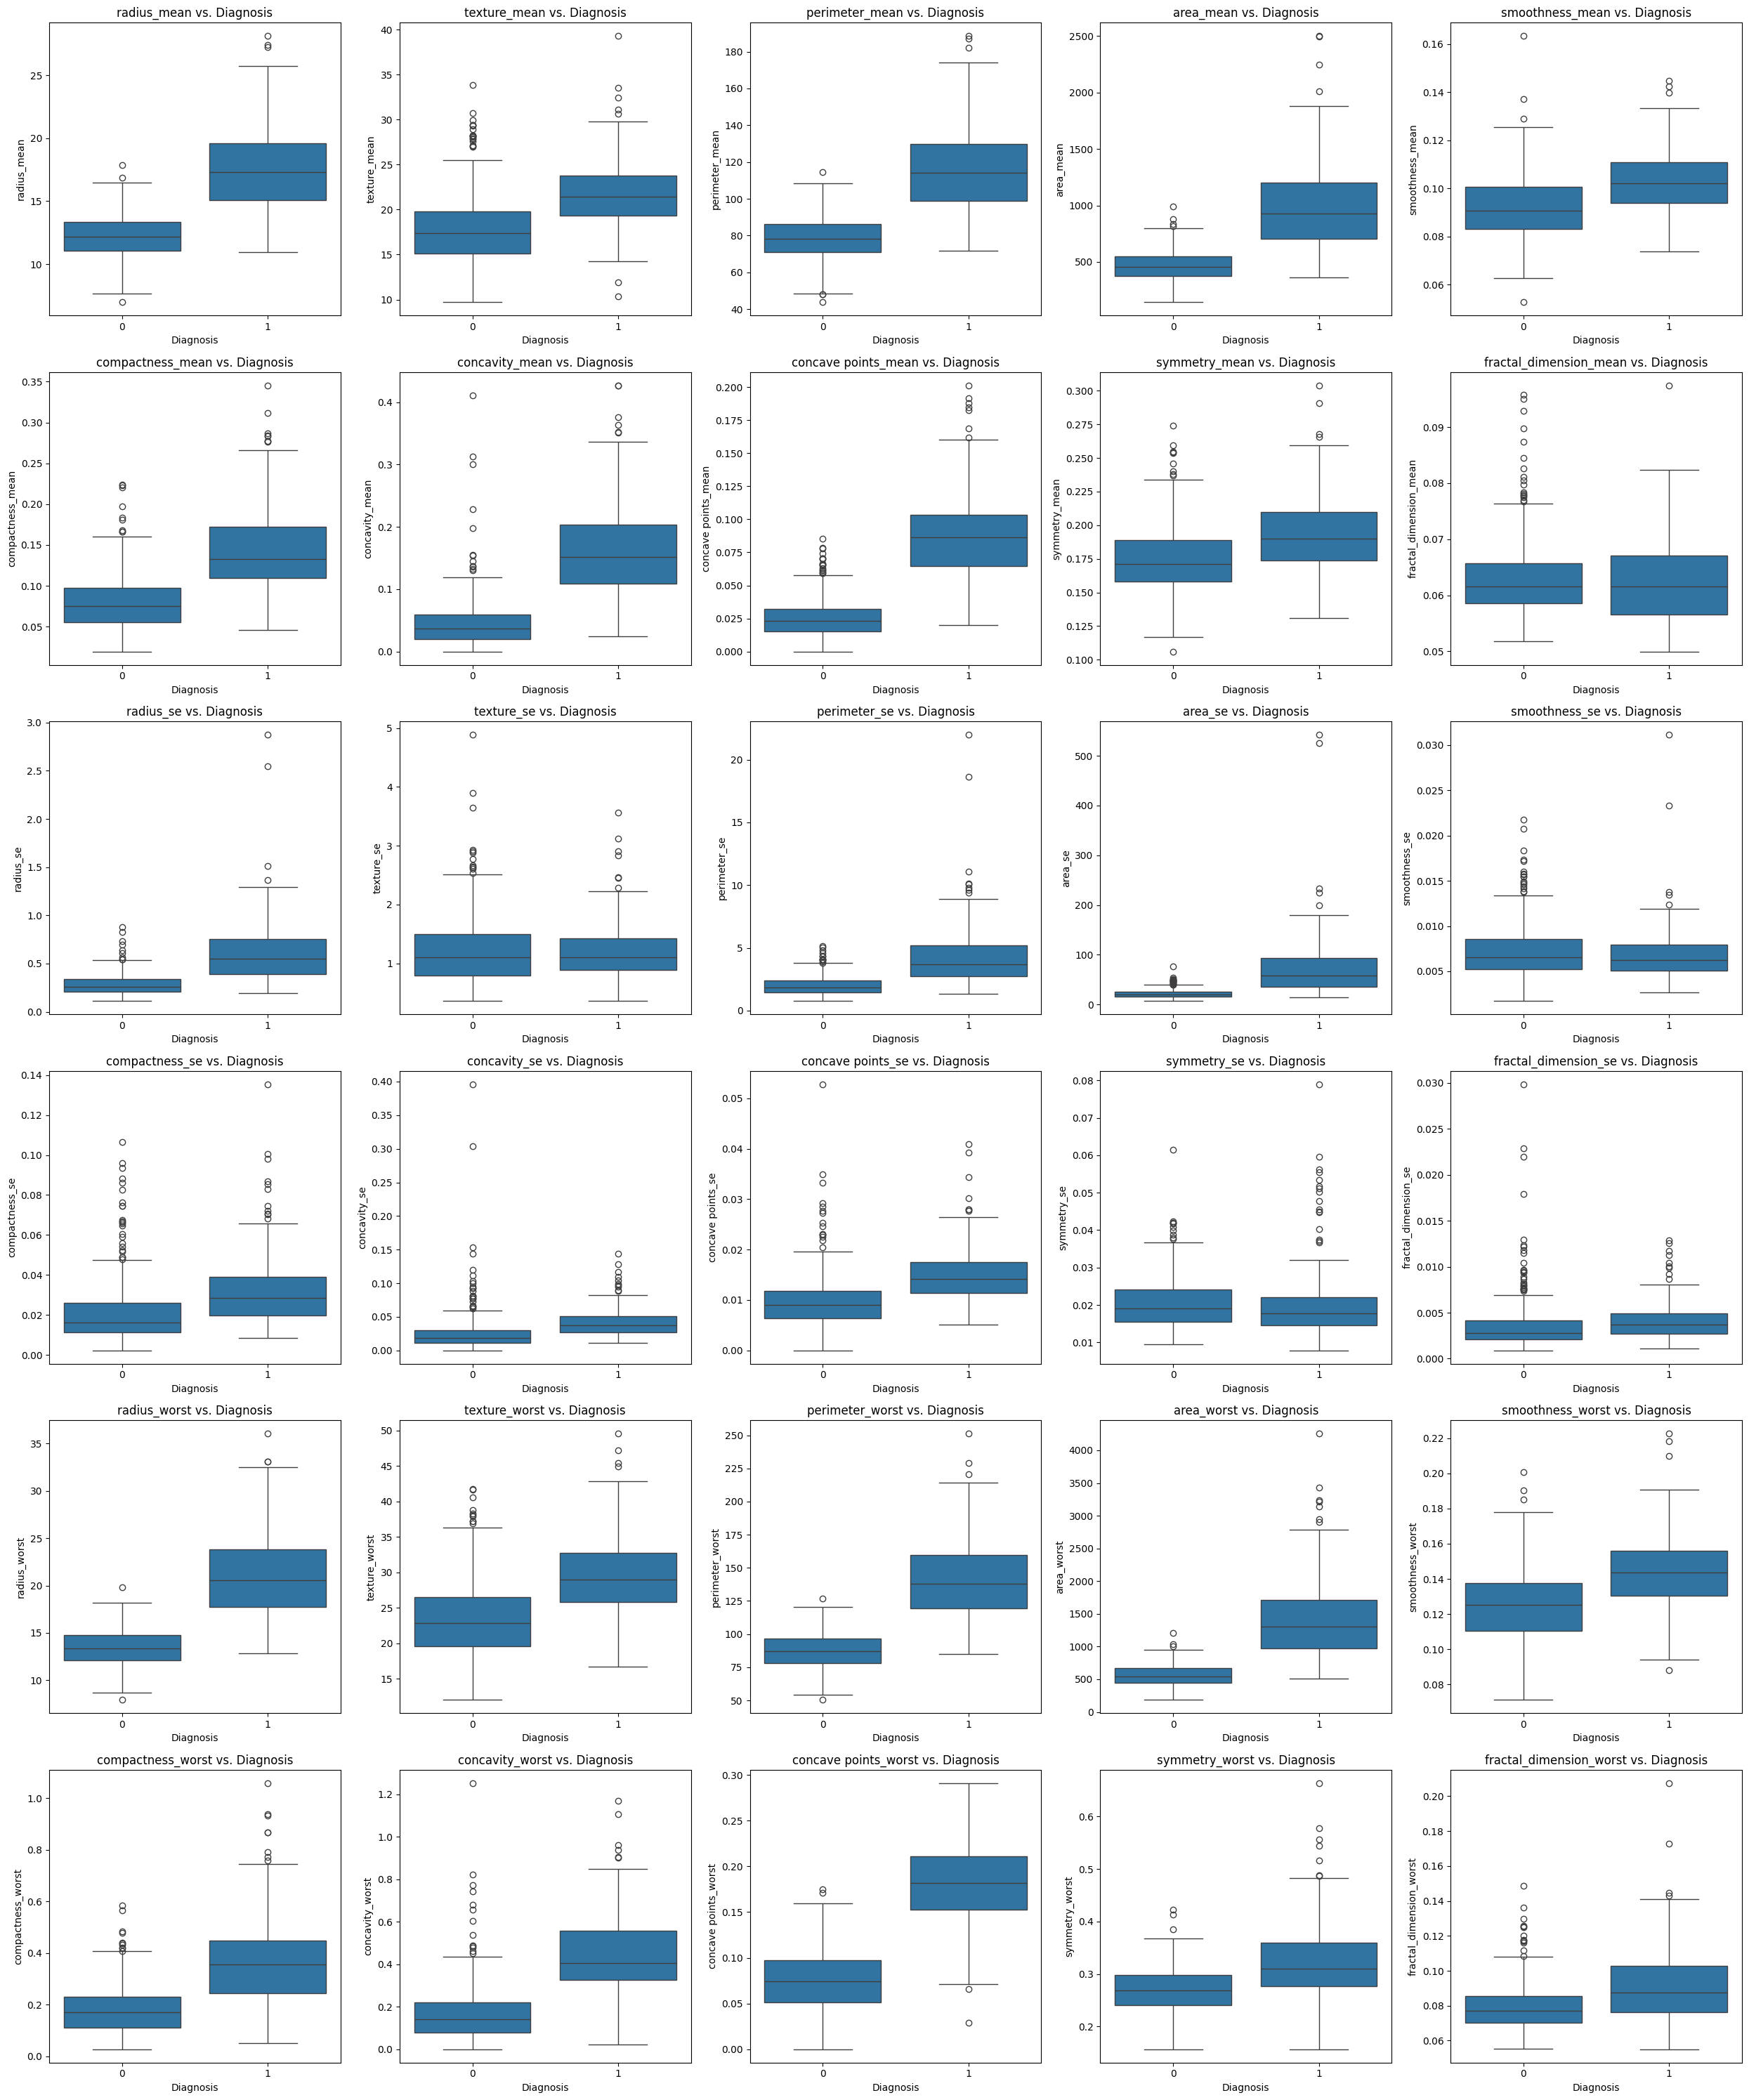

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


feature_columns = X.columns.tolist()


num_features = len(feature_columns)
num_rows = (num_features + 4) // 5  # Gride de 5 plots

plt.figure(figsize=(25, num_rows * 5))

for i, col in enumerate(feature_columns):
    plt.subplot(num_rows, 5, i + 1)
    sns.boxplot(x=y, y=X[col])
    plt.title(f'{col} vs. Diagnosis', fontsize=12)
    plt.xlabel('Diagnosis')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

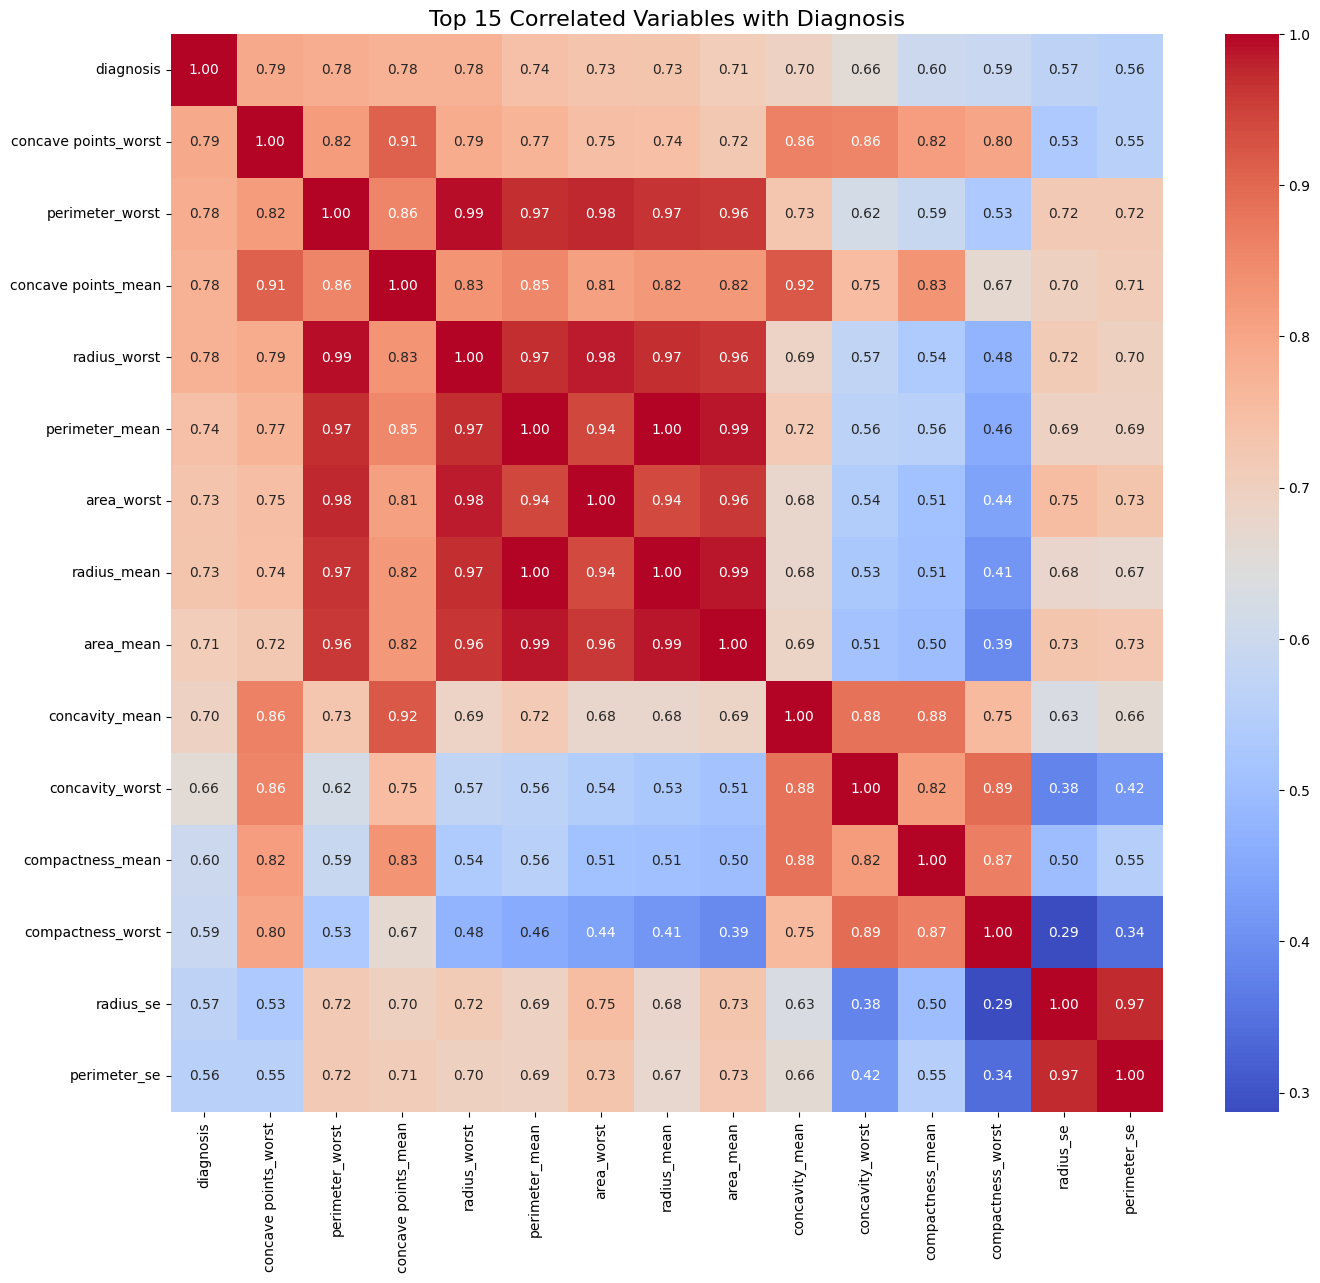

In [ ]:


# Calculamos las correlaciones con diagnostico y las ordenamos

correlations = df_cancer_copy.corr()['diagnosis'].abs().sort_values(ascending=False)

# Separamos el top 15 de correlaciones mas fuertes a diagnostico
top_15_features = correlations.head(15).index.tolist()

# Nuevo dataset para solo el top 15
df_top_features = df_cancer_copy[top_15_features]

# Generamos la matriz con el top 15 de correlaciones
plt.figure(figsize=(16, 14))
sns.heatmap(df_top_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Top 15 viriables correlacionadas con diagnostico', fontsize=16)
plt.show()

# Las variables concave points_worst, perimeter_worst, radius_worst y area_worst muestran una relación fuerte con el diagnóstico.

<Figure size 1500x1500 with 0 Axes>

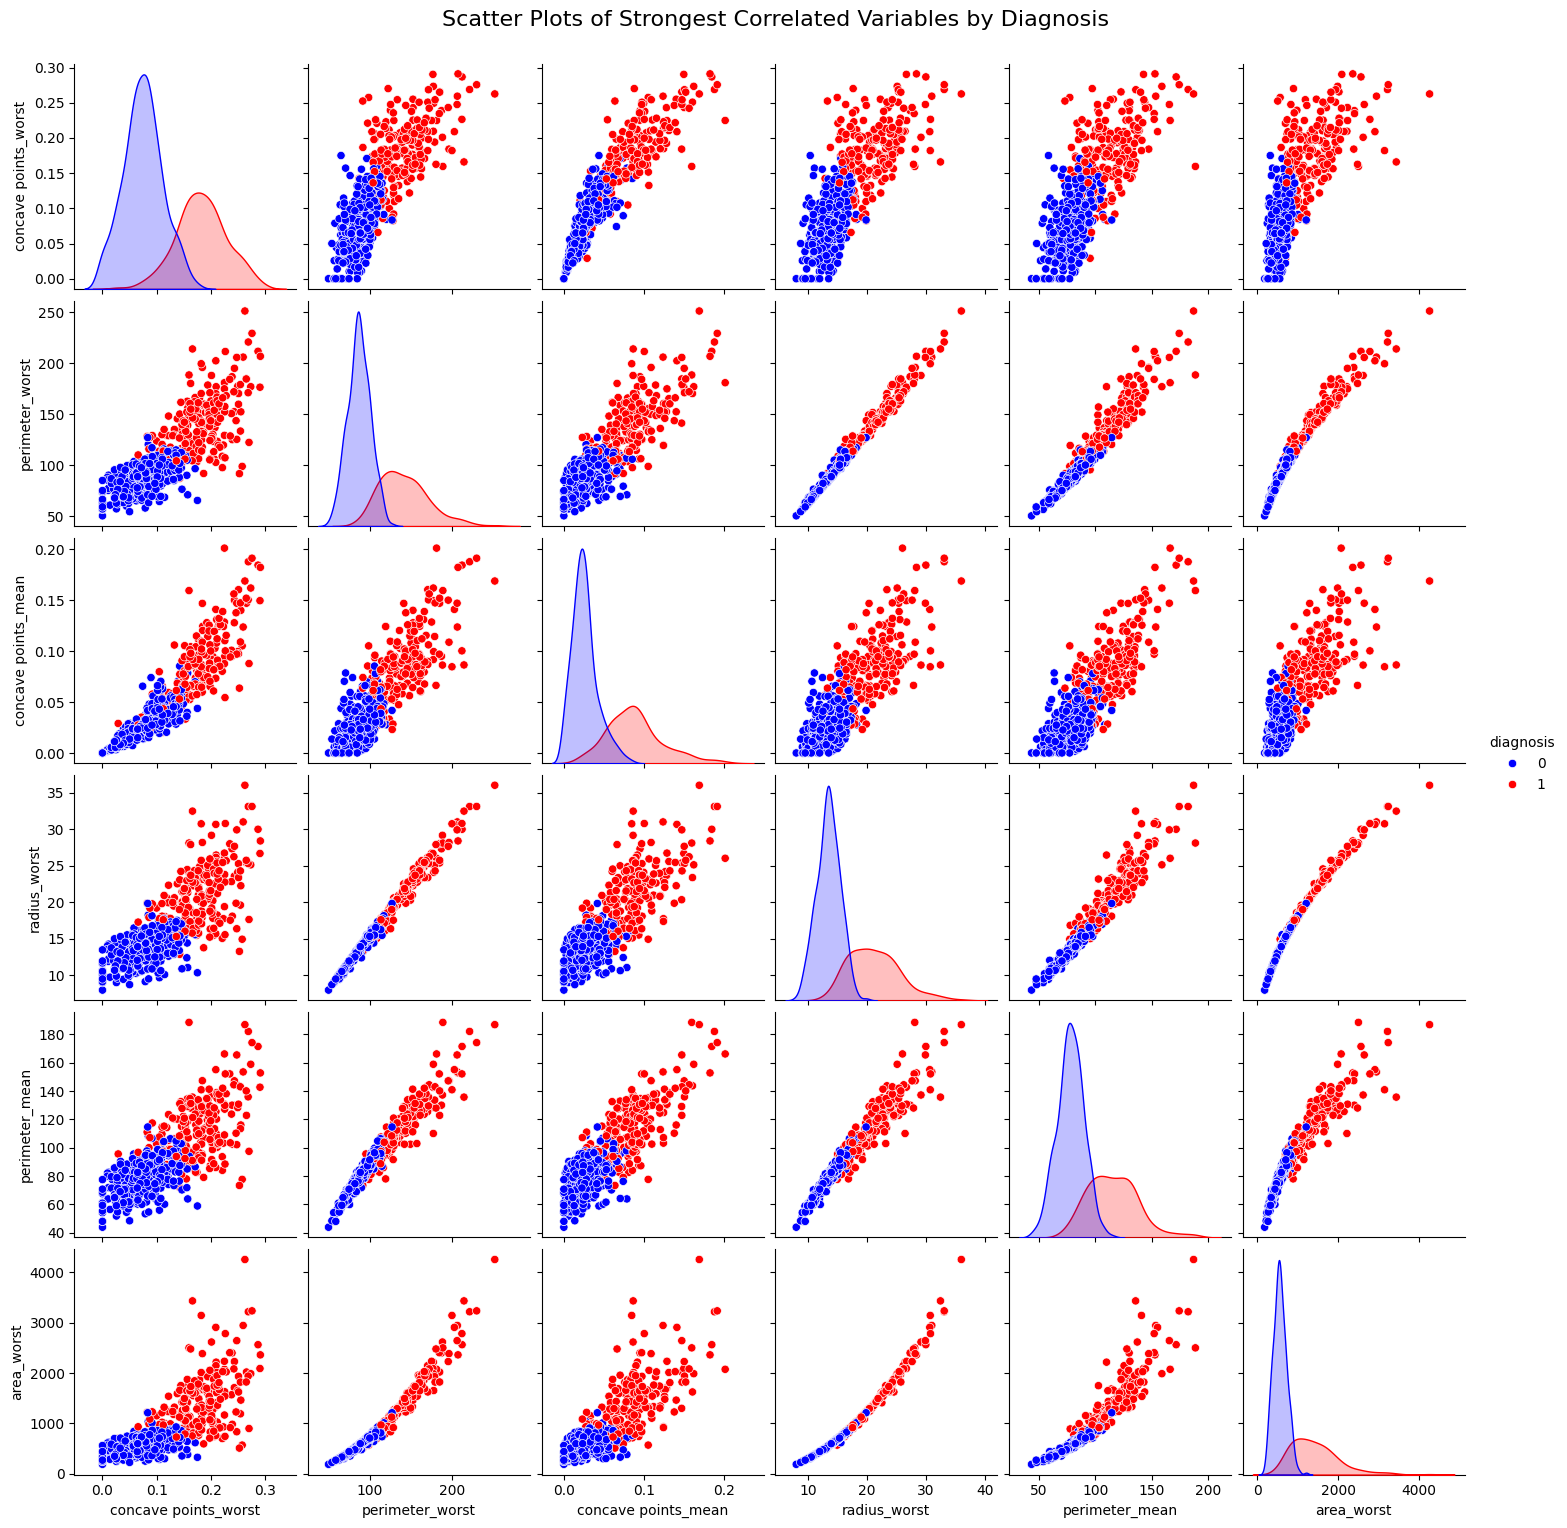

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of top correlated features, excluding 'diagnosis' itself
top_features_for_scatter = [f for f in correlations.head(7).index.tolist() if f != 'diagnosis']

# Include 'diagnosis' for coloring
df_scatter_subset = df_cancer_copy[top_features_for_scatter + ['diagnosis']]

# Generate pair plots for the selected strongest variables, colored by diagnosis
plt.figure(figsize=(15, 15))
sns.pairplot(df_scatter_subset, hue='diagnosis', palette={0: 'blue', 1: 'red'})
plt.suptitle('Scatter Plots of Strongest Correlated Variables by Diagnosis', y=1.02, fontsize=16)
plt.show()

**Observaciones EDA**

En la distribución de la variable diagnosis, se observa que el dataset no está completamente balanceado: existen 212 registros correspondientes a tumores malignos y 357 registros correspondientes a tumores benignos. Aunque hay más casos benignos, ambas clases tienen suficiente representación para entrenar el modelo.

En el scatter plot se observa una separación considerable entre los puntos de ambas clases, lo que sugiere que algunas variables médicas ayudan a diferenciar tumores malignos y benignos. Esto indica que el dataset tiene patrones útiles para un modelo de clasificación como KNN.

Debido a que existe cierto desbalance entre clases, será importante evaluar el modelo no solo con accuracy, sino también con precision, recall, F1-score y matriz de confusión, dando especial atención al recall de la clase maligna.

##Entrenamiento

In [ ]:
X = df_cancer_copy.drop('diagnosis', axis=1)
y = df_cancer_copy['diagnosis']

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_wo

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


###Escalar los datos

KNN, al ser un algoritmo basado en distancias, es sensible a la escala de las características. Por lo tanto, es crucial escalar los datos para asegurar que todas las características contribuyan de manera equitativa a las distancias calculadas. Utilizaremos `MinMaxScaler` para transformar las características a un rango de [0, 1].

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Inicializar el escalador
scaler = MinMaxScaler()

# Ajustar el escalador solo con los datos de entrenamiento (X_train) para evitar data leakage
scaler.fit(X_train)

# Transformar tanto los datos de entrenamiento como los de prueba
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled (first 5 rows):\n", X_train_scaled[:5])
print("\nX_test_scaled (first 5 rows):\n", X_test_scaled[:5])

X_train_scaled (first 5 rows):
 [[0.42780065 0.45755834 0.40709004 0.27753977 0.1937754  0.1451138
  0.07729616 0.16515905 0.23636364 0.14258475 0.09704871 0.18272631
  0.08052584 0.06295877 0.07872999 0.06737527 0.02780303 0.14379617
  0.09452918 0.07418156 0.40056919 0.5826226  0.36550625 0.23712151
  0.30991217 0.1240019  0.11653355 0.34278351 0.27261975 0.19336219]
 [0.25268588 0.0906324  0.24227766 0.13599152 0.39934582 0.15468376
  0.09341612 0.18389662 0.4540404  0.19724576 0.04508419 0.0674947
  0.04301937 0.01985065 0.21524969 0.09167723 0.0425     0.2350824
  0.15981877 0.04675041 0.19815012 0.09648188 0.18208078 0.08943669
  0.44462788 0.09635106 0.09920128 0.32271478 0.24876799 0.08310376]
 [0.27776989 0.39431857 0.26839887 0.1573701  0.12885321 0.19563217
  0.14353327 0.09279324 0.26262626 0.2309322  0.14043093 0.3177599
  0.08457805 0.06432224 0.14610599 0.40853401 0.13068182 0.25402538
  0.26464794 0.23617733 0.2301672  0.39952026 0.20528911 0.11320291
  0.1508948  0.161

In [ ]:
# Verificar que los datos han sido escalados correctamente
print(f"Min value of X_train_scaled: {X_train_scaled.min():.2f}")
print(f"Max value of X_train_scaled: {X_train_scaled.max():.2f}")
print(f"Min value of X_test_scaled: {X_test_scaled.min():.2f}")
print(f"Max value of X_test_scaled: {X_test_scaled.max():.2f}")

Min value of X_train_scaled: 0.00
Max value of X_train_scaled: 1.00
Min value of X_test_scaled: -0.10
Max value of X_test_scaled: 1.28


###Entrenar el Modelo KNN

Con los datos ya escalados, procederemos a entrenar el modelo K-Nearest Neighbors (KNN). Para este ejemplo inicial, utilizaremos `n_neighbors=5`, que es un valor común de inicio.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Se determina k = 7 ya que despues de las pruebas, se determina
#Que es el mejor ya que mantiene el modelo simple y un mejor rendimiento

knn = KNeighborsClassifier(n_neighbors=7)

# Entrenar el modelo con los datos escalados de entrenamiento
knn.fit(X_train_scaled, y_train)

print("Modelo KNN entrenado satisfactoriamente")

Modelo KNN entrenado satisfactoriamente


In [ ]:
# Hacer predicciones en el conjunto de prueba escalado
y_pred = knn.predict(X_test_scaled)

print("Primeras 10 predicciones:")
print(y_pred[:10])

Primeras 10 predicciones:
[0 1 0 0 0 0 1 0 0 0]


Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



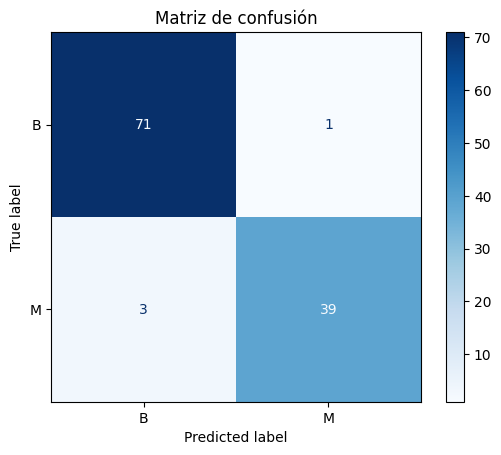

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Imprimir el reporte de clasificación
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))

# Obtener los nombres de las clases (B: 0, M: 1)
class_names = ['B', 'M']

# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de confusión')
plt.show()

**Conclusión KNN**

Se compararon distintos valores de k para el modelo KNN. Aunque todos mantuvieron una exactitud cercana al 96%, se priorizó el recall de la clase maligna debido al contexto médico del problema. Los modelos con k = 7, 9 y 11 obtuvieron el mejor recall para tumores malignos con 0.93. Se seleccionó k = 7 por ofrecer el mismo rendimiento que valores mayores de k, manteniendo un modelo más simple.

###Conclusiones

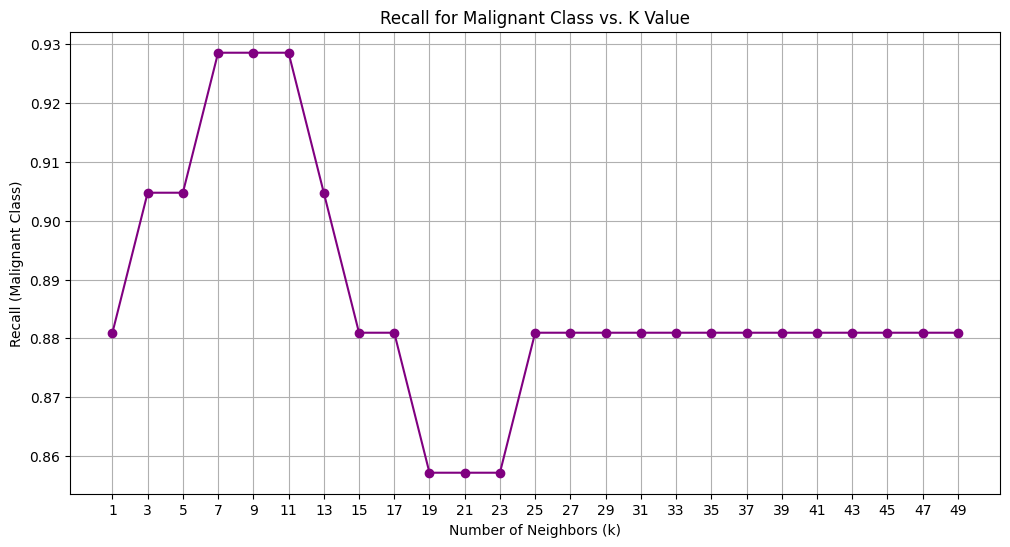

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

k_values = []
recall_malignant = []


for k in range(1, 50, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    report = classification_report(y_test, y_pred, output_dict=True)


    if '1' in report:
        recall_malignant.append(report['1']['recall'])
        k_values.append(k)
    else:

        recall_malignant.append(0.0)
        k_values.append(k)

# Plotting k vs. Recall para clases malignas
plt.figure(figsize=(12, 6))
plt.plot(k_values, recall_malignant, marker='o', linestyle='-', color='purple')
plt.title('Recall para clases malignas vs. K Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Recall (clase Maligna)')
plt.xticks(k_values)
plt.grid(True)
plt.show()


**Conclusiones finales**

Se desarrolló un modelo de clasificación utilizando el algoritmo K-Nearest Neighbors (KNN) para identificar tumores benignos y malignos a partir de características médicas extraídas del dataset. Durante el análisis exploratorio se observó una separación clara entre ambas clases en las variables más relevantes, lo que sugirió desde un inicio la existencia de patrones útiles para la clasificación.

Posteriormente, se evaluaron distintos valores de k utilizando como métrica principal el recall de la clase maligna, debido a la importancia de minimizar los falsos negativos en un contexto médico. Los resultados mostraron que los valores k = 7, 9 y 11 alcanzaron el mejor desempeño, obteniendo un recall cercano al 93% para la detección de tumores malignos.

Se seleccionó finalmente k = 7 como el valor óptimo, ya que logró el mayor recall observado utilizando el menor número de vecinos entre las alternativas de mejor rendimiento. El modelo final alcanzó una exactitud del 96%, una precisión del 97% y un recall del 93% para la clase maligna, demostrando una alta capacidad para diferenciar entre tumores benignos y malignos.

En conclusión, el algoritmo KNN mostró un desempeño sólido para este problema de clasificación médica. Si bien ningún modelo es capaz de eliminar completamente los errores de predicción, los resultados obtenidos indican que el modelo puede servir como una herramienta de apoyo para la detección temprana de tumores, manteniendo una tasa de error baja y una adecuada capacidad para identificar casos malignos. No obstante, su uso debe considerarse complementario al criterio y diagnóstico médico especializado.